# 04 - Regression Models: Predicting AQI Value

Training and comparing 8 regression models to predict the Air Quality Index:

| Model | Library | Type |
|-------|---------|------|
| CatBoost | catboost | Gradient Boosting |
| XGBoost | xgboost | Gradient Boosting |
| LightGBM | lightgbm | Gradient Boosting |
| Random Forest | sklearn | Ensemble |
| Decision Tree | sklearn | Tree |
| Ridge Regression | sklearn | Linear (baseline) |
| Lasso Regression | sklearn | Linear (baseline) |
| SVR | sklearn | Kernel-based |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import sys, os
import joblib

sys.path.insert(0, os.path.abspath('..'))
from config import DATA_PROCESSED, FIGURES_DIR, MODELS_DIR, RANDOM_STATE
from src.evaluation.metrics import regression_metrics, print_regression_comparison

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs(MODELS_DIR / 'regression', exist_ok=True)

## 1. Load Processed Data

In [2]:
df_train = pd.read_parquet(DATA_PROCESSED / 'train.parquet')
df_val = pd.read_parquet(DATA_PROCESSED / 'val.parquet')
df_test = pd.read_parquet(DATA_PROCESSED / 'test.parquet')

print(f"Train: {df_train.shape}, Val: {df_val.shape}, Test: {df_test.shape}")

# Define feature columns (exclude identifiers, target, and derived columns)
exclude_cols = ['City', 'Date', 'AQI', 'AQI_Bucket', 'season',
                'AQI_Calculated', 'AQI_Bucket_Calculated', 'Dominant_Pollutant']
feature_cols = [c for c in df_train.columns if c not in exclude_cols]
target_col = 'AQI'

print(f"Features: {len(feature_cols)}")
print(f"Target: {target_col}")

# Prepare arrays
X_train = df_train[feature_cols].values
y_train = df_train[target_col].values
X_val = df_val[feature_cols].values
y_val = df_val[target_col].values
X_test = df_test[feature_cols].values
y_test = df_test[target_col].values

# Handle any remaining NaN (fill with 0 for tree models, scale for linear)
X_train = np.nan_to_num(X_train, nan=0.0)
X_val = np.nan_to_num(X_val, nan=0.0)
X_test = np.nan_to_num(X_test, nan=0.0)

print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Train: (16849, 146), Val: (3610, 146), Test: (3611, 146)
Features: 141
Target: AQI

X_train: (16849, 141), y_train: (16849,)
X_val: (3610, 141), y_val: (3610,)
X_test: (3611, 141), y_test: (3611,)


In [3]:
# Scale features for linear models and SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("StandardScaler fitted on training data.")

StandardScaler fitted on training data.


## 2. Define and Train All Models

In [4]:
# Model definitions
models = {
    'Ridge': {
        'model': Ridge(alpha=1.0, random_state=RANDOM_STATE),
        'scaled': True
    },
    'Lasso': {
        'model': Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=5000),
        'scaled': True
    },
    'Decision Tree': {
        'model': DecisionTreeRegressor(max_depth=15, min_samples_split=10,
                                       random_state=RANDOM_STATE),
        'scaled': False
    },
    'Random Forest': {
        'model': RandomForestRegressor(n_estimators=200, max_depth=20,
                                       min_samples_split=5, n_jobs=-1,
                                       random_state=RANDOM_STATE),
        'scaled': False
    },
    'SVR': {
        'model': SVR(kernel='rbf', C=100, epsilon=0.1),
        'scaled': True
    },
    'XGBoost': {
        'model': XGBRegressor(n_estimators=500, max_depth=8, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=RANDOM_STATE, n_jobs=-1,
                              early_stopping_rounds=50),
        'scaled': False,
        'eval_set': True
    },
    'LightGBM': {
        'model': LGBMRegressor(n_estimators=500, num_leaves=63, learning_rate=0.05,
                               min_child_samples=20, subsample=0.8,
                               colsample_bytree=0.8, random_state=RANDOM_STATE,
                               n_jobs=-1, verbosity=-1),
        'scaled': False,
        'eval_set': True
    },
    'CatBoost': {
        'model': CatBoostRegressor(iterations=500, depth=8, learning_rate=0.05,
                                    l2_leaf_reg=3, random_seed=RANDOM_STATE,
                                    verbose=0),
        'scaled': False,
        'eval_set': True
    },
}

print(f"Total models to train: {len(models)}")

Total models to train: 8


In [5]:
# Train all models and collect results
results = {}
predictions = {}
train_times = {}

for name, config in models.items():
    print(f"\nTraining {name}...")
    model = config['model']
    use_scaled = config.get('scaled', False)
    use_eval = config.get('eval_set', False)
    
    X_tr = X_train_scaled if use_scaled else X_train
    X_v = X_val_scaled if use_scaled else X_val
    X_te = X_test_scaled if use_scaled else X_test
    
    start = time.time()
    
    if use_eval and name == 'XGBoost':
        model.fit(X_tr, y_train, eval_set=[(X_v, y_val)], verbose=False)
    elif use_eval and name == 'LightGBM':
        model.fit(X_tr, y_train, eval_set=[(X_v, y_val)])
    elif use_eval and name == 'CatBoost':
        model.fit(X_tr, y_train, eval_set=(X_v, y_val), early_stopping_rounds=50)
    else:
        model.fit(X_tr, y_train)
    
    elapsed = time.time() - start
    train_times[name] = elapsed
    
    # Predict on test set
    y_pred = model.predict(X_te)
    predictions[name] = y_pred
    
    # Compute metrics
    metrics = regression_metrics(y_test, y_pred)
    metrics['Train_Time_s'] = round(elapsed, 2)
    results[name] = metrics
    
    print(f"  R2={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.2f}, "
          f"MAE={metrics['MAE']:.2f}, Time={elapsed:.1f}s")
    
    # Save model
    joblib.dump(model, MODELS_DIR / 'regression' / f'{name.lower().replace(" ", "_")}.joblib')

print("\nAll models trained and saved.")


Training Ridge...
  R2=0.5534, RMSE=50.65, MAE=34.05, Time=0.0s

Training Lasso...


  R2=0.5598, RMSE=50.28, MAE=33.65, Time=0.6s

Training Decision Tree...


  R2=0.4774, RMSE=54.78, MAE=23.31, Time=1.7s

Training Random Forest...


  R2=0.7361, RMSE=38.93, MAE=17.02, Time=41.0s



Training SVR...


  R2=0.7986, RMSE=34.01, MAE=18.26, Time=75.1s

Training XGBoost...


  R2=0.7378, RMSE=38.81, MAE=17.30, Time=6.2s

Training LightGBM...


  R2=0.9023, RMSE=23.69, MAE=13.27, Time=4.9s

Training CatBoost...


  R2=0.8318, RMSE=31.08, MAE=16.90, Time=13.5s

All models trained and saved.


## 3. Model Comparison

In [6]:
# Results table
print("=" * 80)
print("REGRESSION MODEL COMPARISON (Test Set)")
print("=" * 80)
results_df = print_regression_comparison(results)
results_df

REGRESSION MODEL COMPARISON (Test Set)
                   R2     RMSE      MAE     MAPE    MedAE  Train_Time_s
LightGBM       0.9023  23.6906  13.2713  16.5280   8.9206          4.89
CatBoost       0.8318  31.0777  16.8953  29.2312   9.9012         13.47
SVR            0.7986  34.0093  18.2600  25.7405  12.5443         75.07
XGBoost        0.7378  38.8050  17.2991  35.3862   8.6966          6.25
Random Forest  0.7361  38.9337  17.0193  34.9200   8.2770         41.05
Lasso          0.5598  50.2834  33.6545  40.1830  26.2583          0.60
Ridge          0.5534  50.6465  34.0519  40.7062  26.5623          0.02
Decision Tree  0.4774  54.7848  23.3085  41.6084  10.3571          1.69


,R2,RMSE,MAE,MAPE,MedAE,Train_Time_s
LightGBM,0.902277,23.690577,13.271328,16.527968,8.920557,4.89
CatBoost,0.831832,31.077686,16.895296,29.231207,9.901225,13.47
SVR,0.798608,34.009342,18.260001,25.740482,12.544339,75.07
XGBoost,0.737806,38.805046,17.299128,35.386171,8.696564,6.25
Random Forest,0.736064,38.933702,17.019325,34.919987,8.276950,41.05
Lasso,0.559753,50.283446,33.654469,40.183036,26.258299,0.60
Ridge,0.553372,50.646496,34.051915,40.706200,26.562295,0.02
Decision Tree,0.477403,54.784792,23.308548,41.608401,10.357143,1.69


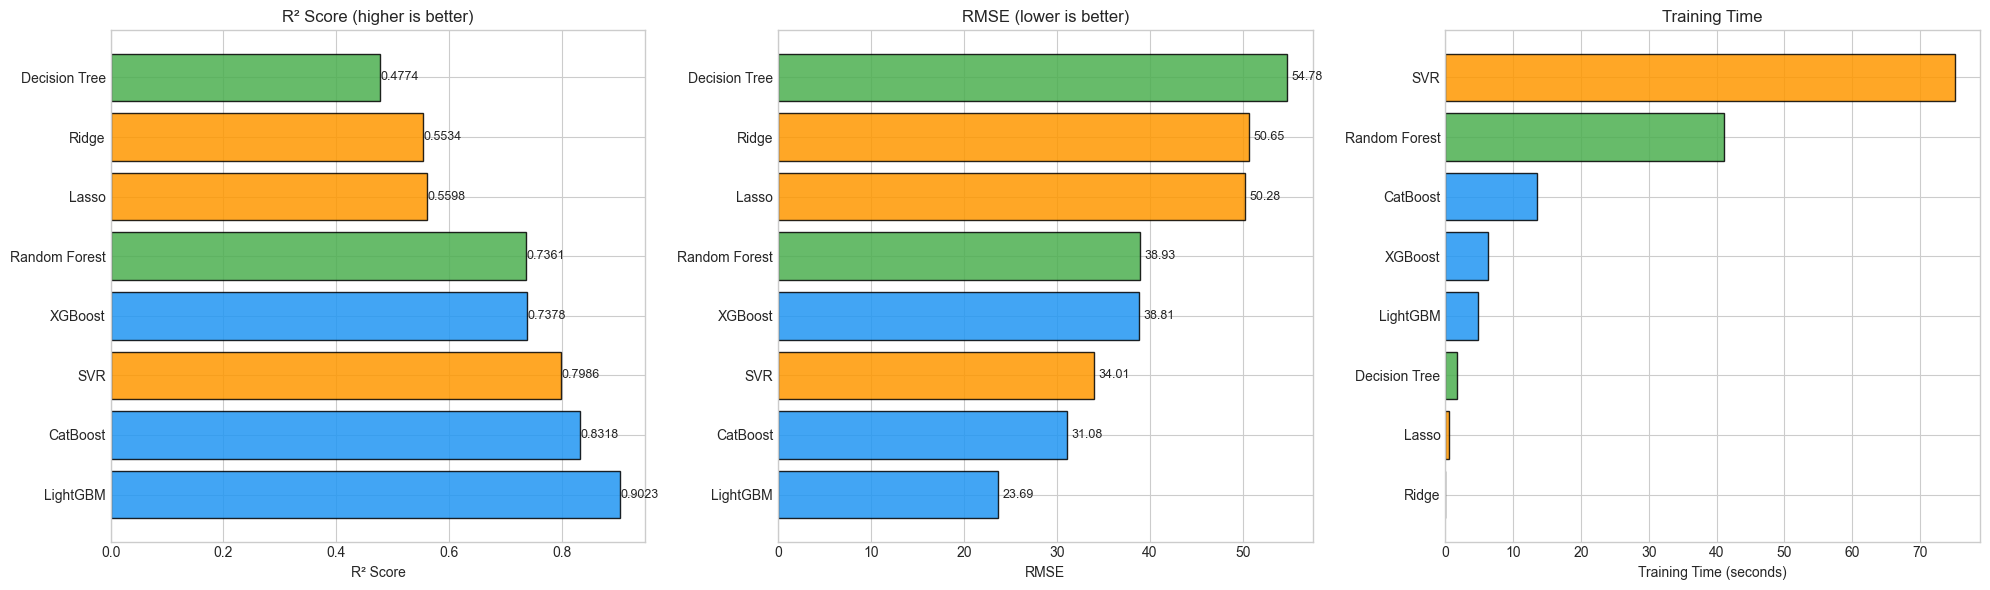

In [7]:
# Comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sorted_models = results_df.index.tolist()
colors = ['#2196F3' if 'Boost' in m or 'LightGBM' in m else '#4CAF50' if 'Forest' in m or 'Tree' in m else '#FF9800' for m in sorted_models]

# R2 Score
axes[0].barh(sorted_models, results_df['R2'], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² Score (higher is better)')
for i, v in enumerate(results_df['R2']):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

# RMSE
rmse_sorted = results_df.sort_values('RMSE')
colors_rmse = ['#2196F3' if 'Boost' in m or 'LightGBM' in m else '#4CAF50' if 'Forest' in m or 'Tree' in m else '#FF9800' for m in rmse_sorted.index]
axes[1].barh(rmse_sorted.index, rmse_sorted['RMSE'], color=colors_rmse, edgecolor='black', alpha=0.85)
axes[1].set_xlabel('RMSE')
axes[1].set_title('RMSE (lower is better)')
for i, v in enumerate(rmse_sorted['RMSE']):
    axes[1].text(v + 0.5, i, f'{v:.2f}', va='center', fontsize=9)

# Training time
time_sorted = results_df.sort_values('Train_Time_s')
colors_time = ['#2196F3' if 'Boost' in m or 'LightGBM' in m else '#4CAF50' if 'Forest' in m or 'Tree' in m else '#FF9800' for m in time_sorted.index]
axes[2].barh(time_sorted.index, time_sorted['Train_Time_s'], color=colors_time, edgecolor='black', alpha=0.85)
axes[2].set_xlabel('Training Time (seconds)')
axes[2].set_title('Training Time')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '15_regression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Predicted vs Actual Plots

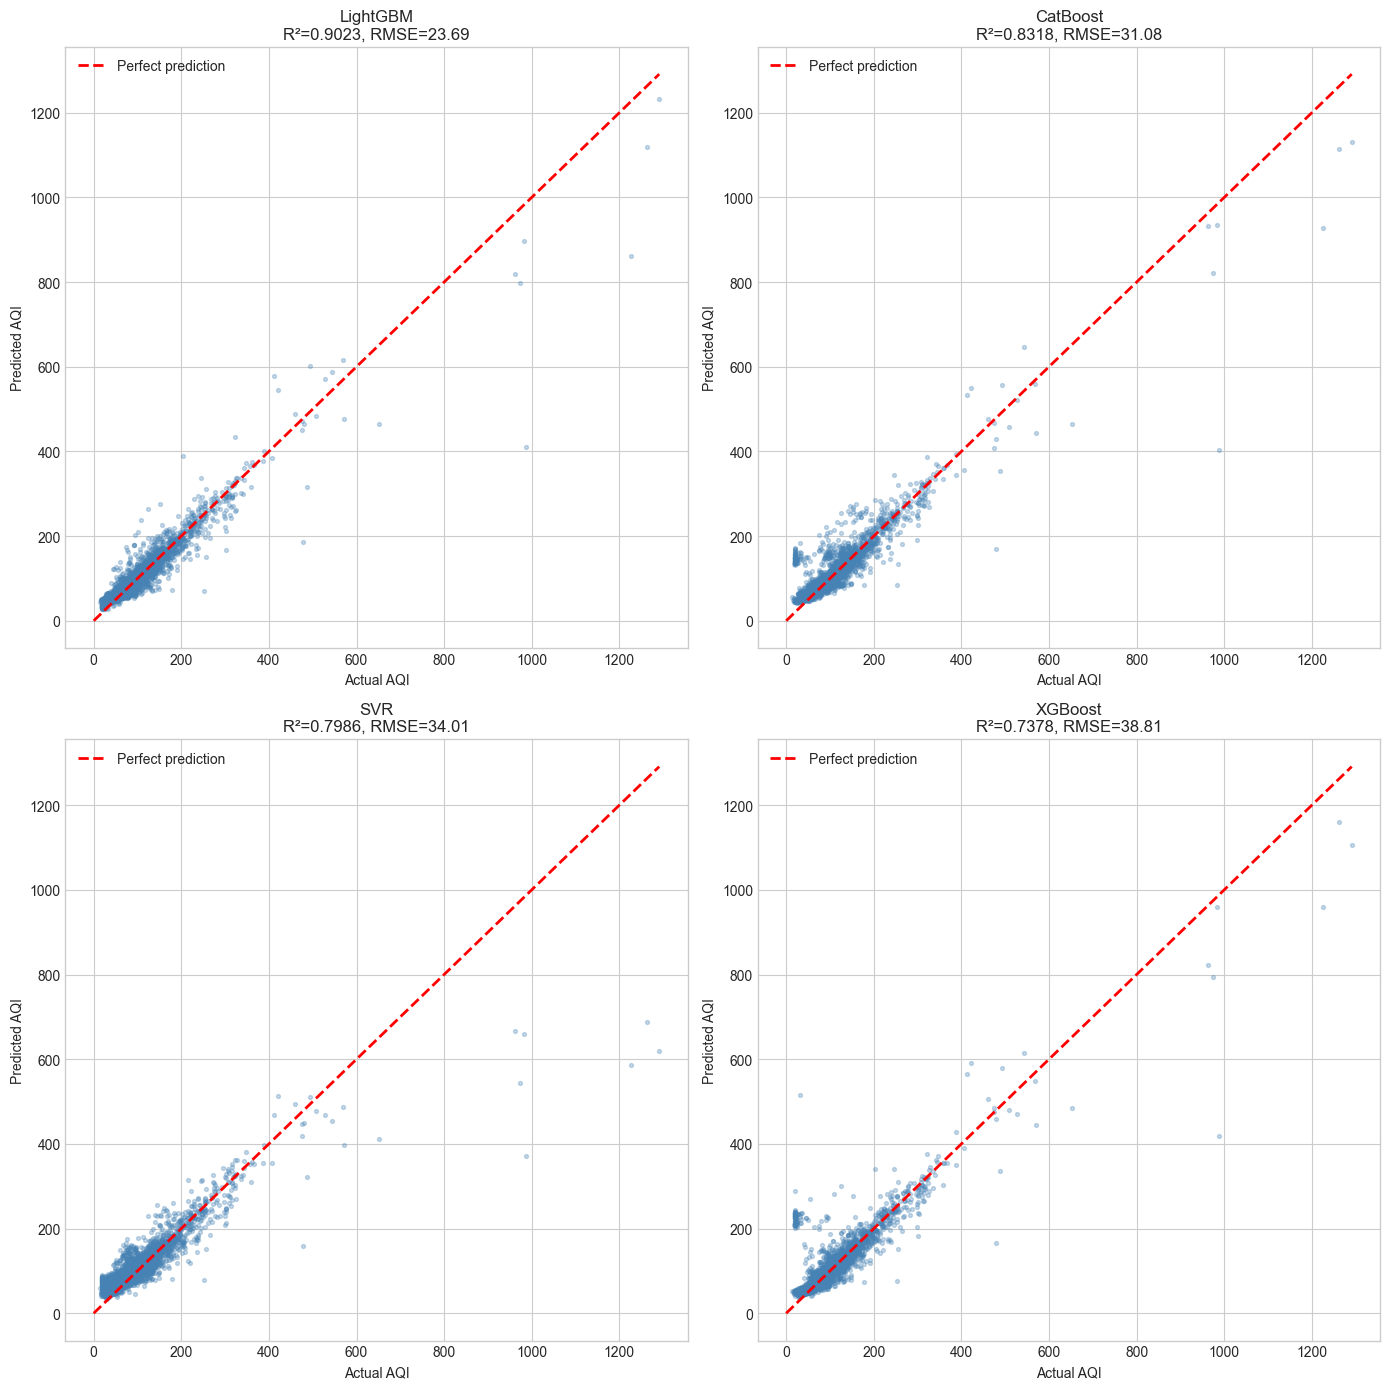

In [8]:
# Top 4 models: predicted vs actual scatter
top4 = results_df.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for i, name in enumerate(top4):
    y_pred = predictions[name]
    r2 = results[name]['R2']
    rmse = results[name]['RMSE']
    
    axes[i].scatter(y_test, y_pred, alpha=0.3, s=8, color='steelblue')
    axes[i].plot([0, y_test.max()], [0, y_test.max()], 'r--', linewidth=2, label='Perfect prediction')
    axes[i].set_xlabel('Actual AQI')
    axes[i].set_ylabel('Predicted AQI')
    axes[i].set_title(f'{name}\nR²={r2:.4f}, RMSE={rmse:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '16_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Residual Analysis

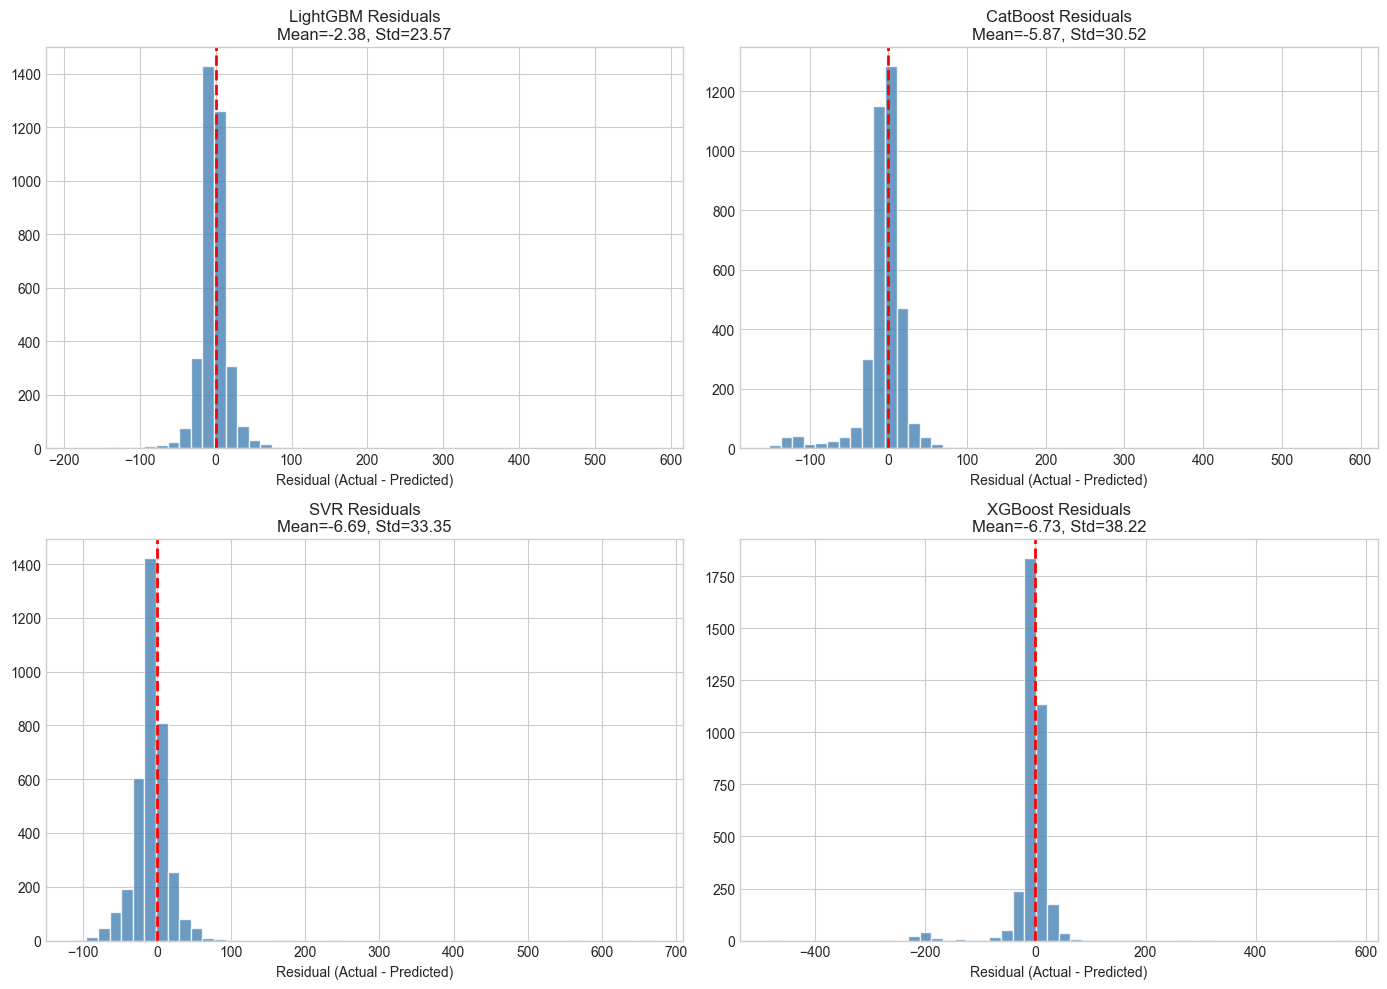

In [9]:
# Residual distributions for top 4 models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, name in enumerate(top4):
    residuals = y_test - predictions[name]
    axes[i].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[i].set_title(f'{name} Residuals\nMean={residuals.mean():.2f}, Std={residuals.std():.2f}')
    axes[i].set_xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '17_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance (Best Model)

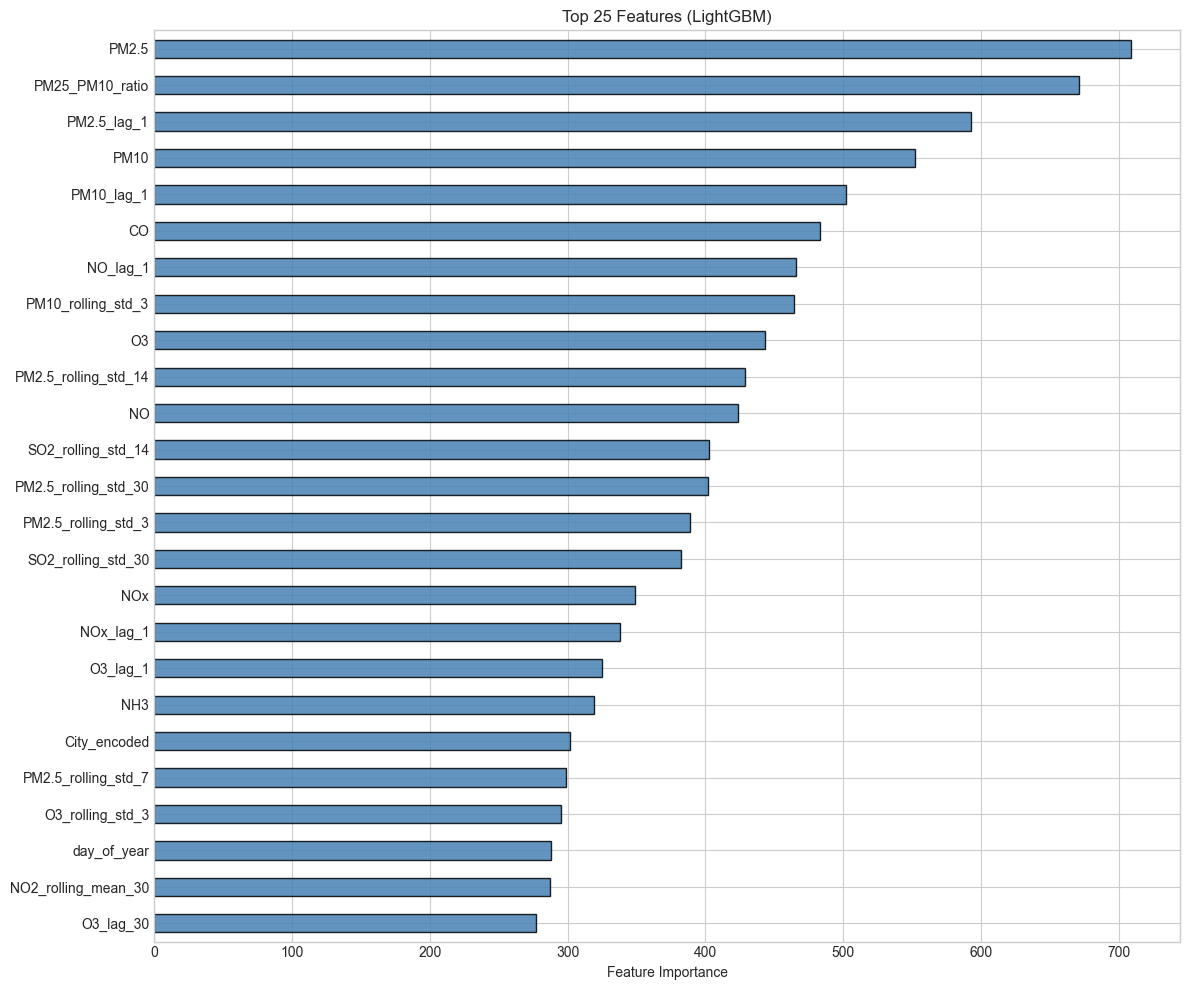


Top 15 features:
PM2.5                   709
PM25_PM10_ratio         671
PM2.5_lag_1             593
PM10                    552
PM10_lag_1              502
CO                      483
NO_lag_1                466
PM10_rolling_std_3      464
O3                      443
PM2.5_rolling_std_14    429
NO                      424
SO2_rolling_std_14      403
PM2.5_rolling_std_30    402
PM2.5_rolling_std_3     389
SO2_rolling_std_30      382


In [10]:
# Feature importance from the best tree-based model
best_model_name = results_df.index[0]
best_model = joblib.load(MODELS_DIR / 'regression' / f'{best_model_name.lower().replace(" ", "_")}.joblib')

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'get_feature_importance'):
    importances = best_model.get_feature_importance()
else:
    importances = None

if importances is not None:
    feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    feat_imp.head(25).sort_values().plot(kind='barh', ax=ax, color='steelblue',
                                         edgecolor='black', alpha=0.85)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 25 Features ({best_model_name})')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '18_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nTop 15 features:")
    print(feat_imp.head(15).round(4).to_string())

## 7. Save Results

In [11]:
# Save comparison table
results_df.to_csv(DATA_PROCESSED / 'regression_results.csv')
print("Results saved to data/processed/regression_results.csv")

# Save scaler
joblib.dump(scaler, MODELS_DIR / 'regression' / 'scaler.joblib')
print("Scaler saved.")

# Final summary
print("\n" + "=" * 60)
print("FINAL REGRESSION RESULTS SUMMARY")
print("=" * 60)
print(f"\nBest Model: {results_df.index[0]}")
print(f"  R²:    {results_df.iloc[0]['R2']:.4f}")
print(f"  RMSE:  {results_df.iloc[0]['RMSE']:.2f}")
print(f"  MAE:   {results_df.iloc[0]['MAE']:.2f}")
print(f"  MAPE:  {results_df.iloc[0]['MAPE']:.2f}%")

Results saved to data/processed/regression_results.csv
Scaler saved.

FINAL REGRESSION RESULTS SUMMARY

Best Model: LightGBM
  R²:    0.9023
  RMSE:  23.69
  MAE:   13.27
  MAPE:  16.53%
